In [1]:
from govuk_bank_holidays.bank_holidays import BankHolidays
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

%matplotlib inline

In [2]:
bank_holidays = BankHolidays()
holidays = pd.DataFrame(bank_holidays.get_holidays())
holidays = holidays[holidays['bunting']]
holidays['holiday_date'] = pd.to_datetime(holidays['date'])
holidays = holidays.drop(columns=['notes', 'title', 'bunting', 'date'])
holidays

,holiday_date
0,2019-01-01
2,2019-05-06
3,2019-05-27
4,2019-12-25
5,2019-12-26
6,2020-01-01
8,2020-05-08
9,2020-05-25
10,2020-12-25
11,2020-12-28


In [3]:
demand_df = pd.read_csv("data/gas_demand.csv")
result_cols = ['date', 'demand']
demand_df = demand_df.drop(columns=['Applicable At', 'Data Item', 'Generated Time', 'Quality Indicator'])
demand_df['date'] = pd.to_datetime(demand_df['Applicable For'], format='%d/%m/%Y')
demand_df['demand'] = demand_df['Value']
demand_df = demand_df[result_cols]
demand_df

,date,demand
0,2026-05-10,9.31935
1,2026-05-09,7.12088
2,2026-05-08,8.97241
3,2026-05-07,10.09847
4,2026-05-06,9.41178
...,...,...
1822,2021-05-14,13.77829
1823,2021-05-13,12.33825
1824,2021-05-12,10.35161
1825,2021-05-11,9.99383


In [4]:
weather_df = pd.read_csv("data/open-meteo-51.49N0.16W23m.csv")

In [5]:
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df.columns= ['weather_date', 'precipitation_mm', 'wind_kmh', 'temp_c']
weather_df

,weather_date,precipitation_mm,wind_kmh,temp_c
0,2021-05-10,1.9,33.4,12.6
1,2021-05-11,0.6,26.0,11.4
2,2021-05-12,1.1,20.8,11.9
3,2021-05-13,5.3,18.3,10.8
4,2021-05-14,0.5,17.8,10.2
...,...,...,...,...
1822,2026-05-06,0.6,14.8,10.9
1823,2026-05-07,0.4,12.3,11.3
1824,2026-05-08,0.0,10.8,13.4
1825,2026-05-09,0.0,14.8,15.4


In [6]:
dataset = pd.merge(demand_df, weather_df, left_on=demand_df['date'], right_on=weather_df['weather_date']).drop(columns=['key_0', 'weather_date'])
dataset['is_holiday'] = dataset['date'].isin(holidays['holiday_date']).astype(int)

In [7]:
dataset['date'] = pd.to_datetime(dataset['date'])
dataset = dataset.sort_values('date').reset_index(drop=True)

dataset['demand_lag1']  = dataset['demand'].shift(1)
dataset['demand_lag7']  = dataset['demand'].shift(7)
dataset['demand_lag14'] = dataset['demand'].shift(14)

dataset['dow'] = dataset['date'].dt.dayofweek + 1
dow_dummies = pd.get_dummies(dataset['date'].dt.dayofweek, prefix='dow', drop_first=True)
dow_dummies.index = dataset.index
dataset = pd.concat([dataset, dow_dummies], axis=1)

dataset['month'] = dataset['date'].dt.month
month_dummies = pd.get_dummies(dataset['month'], prefix='month', drop_first=True)
month_dummies.index = dataset.index
dataset = pd.concat([dataset, month_dummies], axis=1)

dataset['hdd'] = (15.5 - dataset['temp_c']).clip(lower=0)
dataset['time_trend'] = range(len(dataset))

dataset = dataset.dropna().reset_index(drop=True)

dataset

,date,demand,precipitation_mm,wind_kmh,temp_c,is_holiday,demand_lag1,demand_lag7,demand_lag14,dow,...,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,hdd,time_trend
0,2021-05-24,13.96385,10.4,31.8,10.2,0,13.59049,12.58891,9.43420,1,...,True,False,False,False,False,False,False,False,5.3,14
1,2021-05-25,14.07083,0.8,27.8,10.6,0,13.96385,12.18641,9.99383,2,...,True,False,False,False,False,False,False,False,4.9,15
2,2021-05-26,12.57374,0.6,18.8,10.8,0,14.07083,11.73503,10.35161,3,...,True,False,False,False,False,False,False,False,4.7,16
3,2021-05-27,9.83858,0.0,13.0,13.3,0,12.57374,13.16365,12.33825,4,...,True,False,False,False,False,False,False,False,2.2,17
4,2021-05-28,9.20728,0.5,9.8,14.1,0,9.83858,13.84066,13.77829,5,...,True,False,False,False,False,False,False,False,1.4,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1808,2026-05-06,9.41178,0.6,14.8,10.9,0,8.57923,8.56468,10.48353,3,...,True,False,False,False,False,False,False,False,4.6,1822
1809,2026-05-07,10.09847,0.4,12.3,11.3,0,9.41178,7.72919,10.70186,4,...,True,False,False,False,False,False,False,False,4.2,1823
1810,2026-05-08,8.97241,0.0,10.8,13.4,0,10.09847,7.31608,10.15964,5,...,True,False,False,False,False,False,False,False,2.1,1824
1811,2026-05-09,7.12088,0.0,14.8,15.4,0,8.97241,6.60771,9.21944,6,...,True,False,False,False,False,False,False,False,0.1,1825


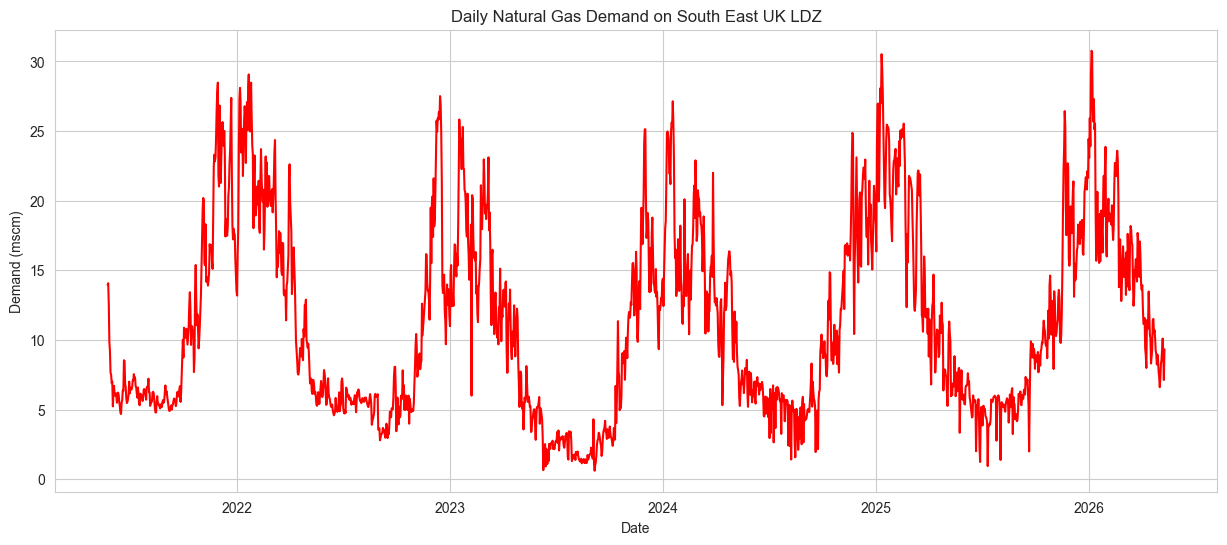

In [8]:
plt.figure(figsize = (15, 6))
plt.plot(dataset['date'], dataset['demand'], 'r')
plt.xlabel("Date")
plt.ylabel("Demand (mscm)")
plt.title("Daily Natural Gas Demand on South East UK LDZ")
plt.show()

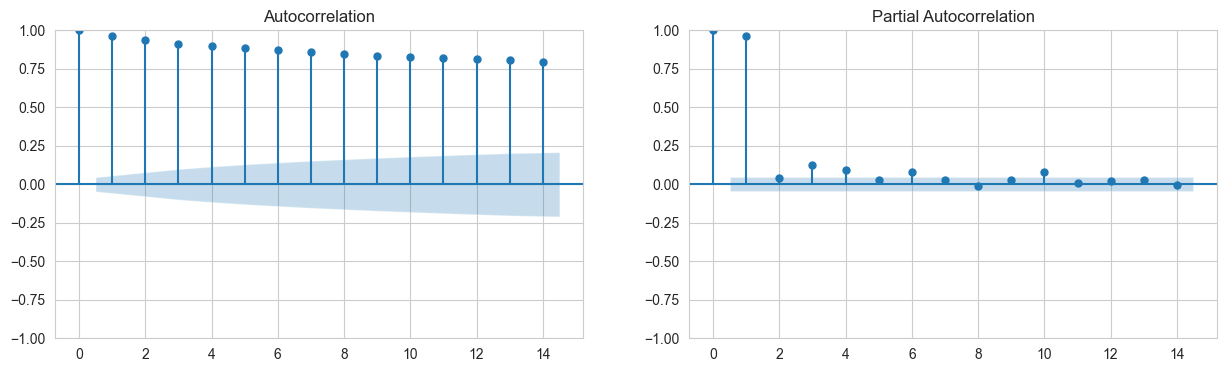

In [9]:
fig, axes = plt.subplots(1, 2, figsize = (15, 4))

fig = sm.graphics.tsa.plot_acf(dataset['demand'], lags=14, ax=axes[0])
fig = sm.graphics.tsa.plot_pacf(dataset['demand'], lags=14, ax=axes[1])

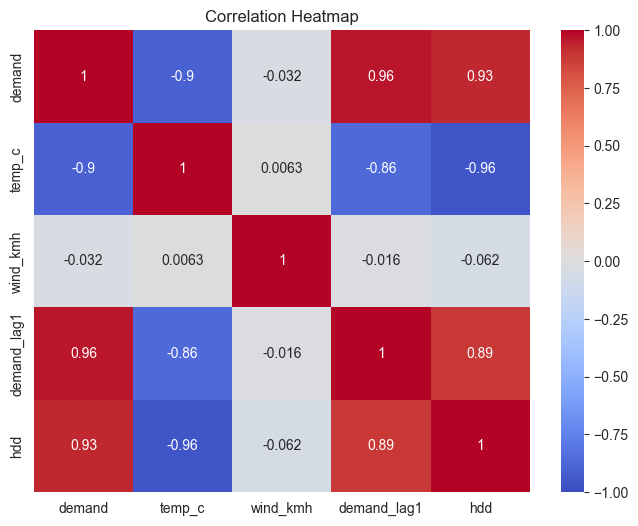

In [10]:
df_corr = dataset[['demand', 'temp_c', 'wind_kmh', 'demand_lag1', 'hdd']]

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(method='pearson'), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [11]:
dataset[['demand', 'temp_c', 'hdd', 'wind_kmh', 'precipitation_mm']].describe()

,demand,temp_c,hdd,wind_kmh,precipitation_mm
count,1813.000000,1813.000000,1813.000000,1813.000000,1813.000000
mean,11.315601,11.917540,4.452344,20.144126,2.047711
std,6.794403,5.524973,4.407522,7.811439,4.068300
min,0.608830,-3.000000,0.000000,3.500000,0.000000
25%,5.689590,8.100000,0.000000,14.200000,0.000000
50%,9.823720,11.900000,3.600000,19.000000,0.300000
75%,16.313480,16.200000,7.400000,24.800000,2.300000
max,30.763630,29.100000,18.500000,68.000000,48.700000


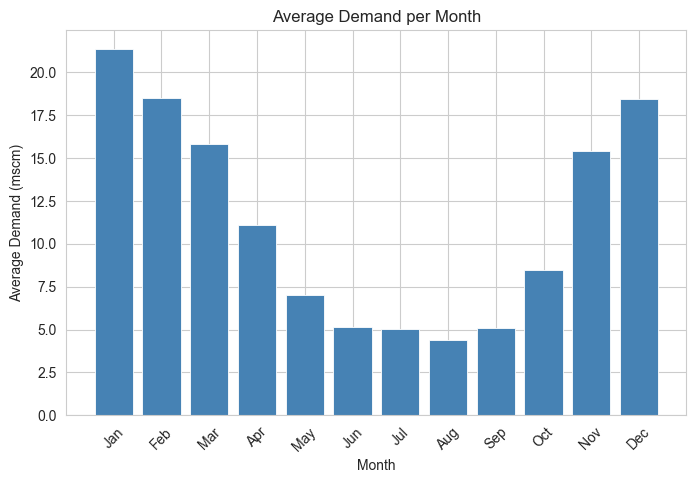

In [12]:
df = dataset.copy()

monthly = df.groupby(["month"])["demand"].mean().reset_index()
monthly = monthly.sort_values("month")

fig, ax = plt.subplots(figsize=(8, 5))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.bar(month_names, monthly["demand"], color="steelblue", edgecolor="white", linewidth=0.6)
ax.set_title("Average Demand per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Demand (mscm)")
ax.tick_params(axis="x", rotation=45)

plt.show()

In [13]:
dataset.to_csv("dataset.csv")